# 03 · Occupational employment and wages (BLS OEWS) × GPT exposure

**Questions.**
1. How did employment and the wage distribution of software occupations change between May 2019 and May 2025?
2. Across *all* ~800 detailed occupations, did employment or wages of more GPT-exposed occupations diverge after 2022, and was there a pre-trend?

**Data.** BLS OEWS national estimates for May 2019 to May 2025, and Eloundou et al. (2024) exposure scores.

**The 10th wage percentile as a junior proxy.** OEWS has no experience variable. The 10th percentile (P10) is a rough stand-in for entry-level pay and P90 for senior pay. The proxy is imperfect: if firms hire fewer juniors, P10 **rises mechanically** because the low end of the distribution empties out.

**Caveats.** OEWS estimates pool three years of survey panels, so year-to-year changes are smoothed and lag real changes. May 2019 and 2020 use hybrid SOC codes; section 1 harmonizes them.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().resolve().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from common import *
set_style()
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

In [2]:
oews = pd.concat([load_oews(y) for y in OEWS_YEARS], ignore_index=True)
print(oews.groupby("YEAR").OCC_CODE.nunique().rename("n occupations").to_string())

YEAR
2019    790
2020    790
2021    832
2022    831
2023    832
2024    832
2025    831


## 1. Employment in computer occupations (harmonized SOC), index May 2022 = 100

In [3]:
HYBRID = {"15-1252": "15-1256", "15-1253": "15-1256", "15-1254": "15-1257", "15-1255": "15-1257"}
GROUPS = {"15-1256": "Software developers & QA testers", "15-1251": "Computer programmers",
          "15-1257": "Web developers & digital designers", "15-1232": "Computer user support specialists",
          "00-0000": "All occupations"}
h = oews.assign(code=oews.OCC_CODE.replace(HYBRID))
emp = h[h.code.isin(GROUPS)].groupby(["YEAR", "code"]).TOT_EMP.sum().unstack("code").rename(columns=GROUPS)
emp = emp[list(GROUPS.values())]
emp_idx = emp / emp.loc[2022] * 100

emp_tab = (emp / 1000).round(1)
emp_tab.loc["% chg 2019-22"] = ((emp.loc[2022] / emp.loc[2019] - 1) * 100).round(1)
emp_tab.loc["% chg 2022-25"] = ((emp.loc[2025] / emp.loc[2022] - 1) * 100).round(1)
print("Employment (thousands)")
emp_tab

Employment (thousands)


code,Software developers & QA testers,Computer programmers,Web developers & digital designers,Computer user support specialists,All occupations
YEAR,,,,,
2019,1406.9,199.5,148.3,647.3,146875.5
2020,1476.8,178.1,156.2,634.8,139099.6
2021,1554.3,152.6,167.2,654.3,140886.3
2022,1731.2,132.7,186.0,696.8,147886.0
2023,1859.9,120.4,196.4,689.7,151853.9
2024,1854.2,109.9,190.3,697.2,154187.4
2025,1874.6,92.2,183.5,717.2,155495.7
% chg 2019-22,23.1,-33.5,25.4,7.6,0.7
% chg 2022-25,8.3,-30.5,-1.3,2.9,5.1


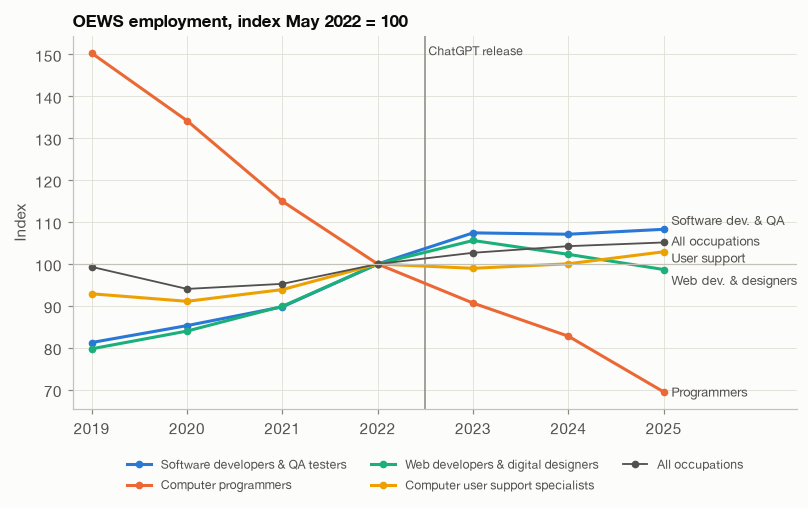

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 4.4))
short = {"Software developers & QA testers": "Software dev. & QA", "Computer programmers": "Programmers",
         "Web developers & digital designers": "Web dev. & designers",
         "Computer user support specialists": "User support", "All occupations": "All occupations"}
nudge = {"Software developers & QA testers": 6, "All occupations": 1, "Computer user support specialists": -4,
         "Web developers & digital designers": -7, "Computer programmers": 0}   # end labels sit close together
for col, c in zip(emp_idx.columns, SERIES + [INK_2]):
    ax.plot(emp_idx.index, emp_idx[col], color=c, marker="o", ms=4, label=col,
            lw=1.2 if col == "All occupations" else 2)
    label_end(ax, 2025, emp_idx[col].iloc[-1], short[col], dy=nudge[col])
ax.axhline(100, color=BASELINE, lw=0.8)
mark_chatgpt(ax, x=2022.5)
ax.set_xlim(2018.8, 2026.4)
ax.set_xticks(range(2019, 2026))
ax.set_title("OEWS employment, index May 2022 = 100")
ax.set_ylabel("Index")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=8)
save(fig, "03_oews_computer_employment");

## 2. Wage distribution of software developers (SOC 15-1252, May 2021 to May 2025)

In [5]:
pcts = {"A_PCT10": "P10", "A_PCT25": "P25", "A_MEDIAN": "P50", "A_PCT75": "P75", "A_PCT90": "P90"}
def dist(code, years=range(2021, 2026)):
    return oews[(oews.OCC_CODE == code) & oews.YEAR.isin(years)].set_index("YEAR")[list(pcts)].rename(columns=pcts)
sd, prog, allocc = dist("15-1252"), dist("15-1251"), dist("00-0000")
for d in (sd, prog, allocc):
    d["P90/P10"] = d.P90 / d.P10
print("Software developers, annual wage percentiles (nominal $)")
display(sd.round(2))

cols = list(pcts.values())
growth = pd.DataFrame({
    "Software dev. 2021-22": sd.loc[2022, cols] / sd.loc[2021, cols] - 1,
    "Software dev. 2022-25": sd.loc[2025, cols] / sd.loc[2022, cols] - 1,
    "Programmers 2022-25": prog.loc[2025, cols] / prog.loc[2022, cols] - 1,
    "All occupations 2022-25": allocc.loc[2025, cols] / allocc.loc[2022, cols] - 1,
}) * 100
print("Nominal growth by percentile (%)")
growth.round(1)

Software developers, annual wage percentiles (nominal $)


,P10,P25,P50,P75,P90,P90/P10
YEAR,,,,,,
2021,64470.0,90870.0,120730.0,151960.0,168570.0,2.61
2022,71280.0,96790.0,127260.0,161480.0,198100.0,2.78
2023,77020.0,101200.0,132270.0,167540.0,208620.0,2.71
2024,79850.0,103050.0,133080.0,169000.0,211450.0,2.65
2025,82460.0,105210.0,135980.0,171980.0,214670.0,2.60


Nominal growth by percentile (%)


,Software dev. 2021-22,Software dev. 2022-25,Programmers 2022-25,All occupations 2022-25
P10,10.6,15.7,6.3,14.1
P25,6.5,8.7,4.7,12.8
P50,5.4,6.9,2.6,10.1
P75,6.3,6.5,5.3,9.6
P90,17.5,8.4,1.8,16.6


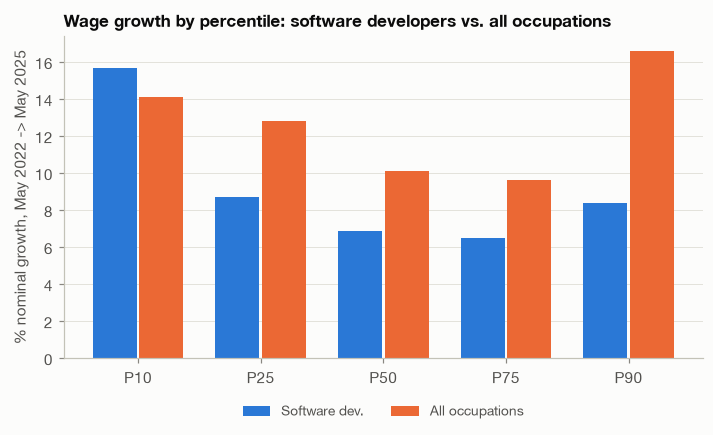

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))
xpos = np.arange(len(cols))
w = 0.36
for i, (col, c) in enumerate([("Software dev. 2022-25", BLUE), ("All occupations 2022-25", ORANGE)]):
    ax.bar(xpos + (i - 0.5) * (w + 0.02), growth[col], width=w, color=c, label=col.replace(" 2022-25", ""))
ax.set_xticks(xpos, cols)
ax.grid(axis="x", visible=False)
ax.set_ylabel("% nominal growth, May 2022 -> May 2025")
ax.set_title("Wage growth by percentile: software developers vs. all occupations")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2)
save(fig, "03_oews_wage_growth_by_percentile");

## 3. Exposure event study across all detailed occupations

$y_{ot} = \alpha_o + \gamma_t + \sum_{t \neq 2022} \beta_t\,(z_o \times \mathbb{1}[t]) + \varepsilon_{ot}$

Here $z_o$ is the standardized Eloundou et al. β exposure (GPT-4 rated) and $y$ is log employment or a log wage percentile. The regression is weighted by May 2022 employment, with standard errors clustered by occupation. $\beta_t$ is the change in the outcome, relative to May 2022, for an occupation one SD more exposed. Coefficients for 2019–2021 test for pre-trends.

Two panels:
- **2021–2025:** all detailed SOC-2018 codes.
- **2019–2025:** only codes that appear unchanged in every year.

In [7]:
exp6 = load_exposure()
aioe = load_aioe()   # Felten et al. (2021), robustness measure
det = oews[oews.O_GROUP == "detailed"]

def build_panel(years):
    years = list(years)
    p = det[det.YEAR.isin(years)].dropna(subset=["TOT_EMP"])
    full = p.groupby("OCC_CODE").YEAR.nunique() == len(years)
    p = p[p.OCC_CODE.isin(full[full].index)].merge(exp6, left_on="OCC_CODE", right_index=True).join(aioe, on="OCC_CODE")
    p["w"] = p.OCC_CODE.map(p[p.YEAR == 2022].set_index("OCC_CODE").TOT_EMP)
    occ = p.drop_duplicates("OCC_CODE")
    for src, z in [("dv_rating_beta", "z"), ("human_rating_beta", "z_h"), ("aioe", "z_aioe")]:
        p[z] = (p[src] - occ[src].mean()) / occ[src].std()
    for c in ["TOT_EMP", "A_MEDIAN", "A_PCT10", "A_PCT90"]:
        p["log_" + c.lower()] = np.log(p[c])
    return p

p21, p19 = build_panel(range(2021, 2026)), build_panel(range(2019, 2026))
print(f"2021-2025 panel: {p21.OCC_CODE.nunique()} occupations; 2019-2025 panel: {p19.OCC_CODE.nunique()} occupations")
print(f"Share of May-2022 employment covered: {p21[p21.YEAR==2022].TOT_EMP.sum() / oews.query('YEAR==2022 and OCC_CODE==\"00-0000\"').TOT_EMP.iloc[0]:.0%}")
print(f"Occupations with a Felten AIOE match: {p19.drop_duplicates('OCC_CODE').aioe.notna().mean():.0%} of the 2019-25 panel")
print("Correlation of GPT-4 beta and AIOE across occupations:", round(p19.drop_duplicates("OCC_CODE")[["dv_rating_beta", "aioe"]].corr().iloc[0, 1], 2))
pct = exp6.dv_rating_beta.rank(pct=True)
print("Exposure percentile (GPT-4 β) of software occupations:",
      {c: f"{pct.get(c, np.nan):.0%}" for c in ["15-1251", "15-1252", "15-1253", "15-1254"]})

def exposure_event_study(p, outcome, zvar="z", ref=2022, weighted=True):
    d = p.dropna(subset=[outcome, zvar]).copy()
    terms = []
    for y in sorted(d.YEAR.unique()):
        if y != ref:
            d[f"zx{y}"] = d[zvar] * (d.YEAR == y)
            terms.append(f"zx{y}")
    f = f"{outcome} ~ {' + '.join(terms)} + C(OCC_CODE) + C(YEAR)"
    fit = (smf.wls(f, data=d, weights=d.w) if weighted else smf.ols(f, data=d)).fit(
        cov_type="cluster", cov_kwds={"groups": pd.factorize(d.OCC_CODE)[0]})
    out = pd.DataFrame({"coef": fit.params[terms], "se": fit.bse[terms]})
    out.index = [int(t[2:]) for t in terms]
    out.loc[ref] = [0.0, 0.0]
    return out.sort_index()

specs = {
    "Employment, 2019-25 panel": (p19, "log_tot_emp", "z", True),
    "Employment, 2021-25 panel": (p21, "log_tot_emp", "z", True),
    "Employment, 2019-25, human exposure": (p19, "log_tot_emp", "z_h", True),
    "Employment, 2019-25, Felten AIOE": (p19, "log_tot_emp", "z_aioe", True),
    "Employment, 2019-25, unweighted": (p19, "log_tot_emp", "z", False),
    "Median wage, 2019-25": (p19, "log_a_median", "z", True),
    "P10 wage, 2019-25": (p19, "log_a_pct10", "z", True),
    "P90 wage, 2019-25": (p19, "log_a_pct90", "z", True),
}
es = {k: exposure_event_study(p, outcome, zvar=z, weighted=wt) for k, (p, outcome, z, wt) in specs.items()}
es_tab = pd.concat({k: v.coef.map("{:+.3f}".format) + v.se.map(" ({:.3f})".format) for k, v in es.items()}, axis=1).T
print("Coefficient on (exposure z x year), log points; clustered SE in parentheses; ref = 2022")
es_tab

2021-2025 panel: 770 occupations; 2019-2025 panel: 706 occupations
Share of May-2022 employment covered: 93%
Occupations with a Felten AIOE match: 93% of the 2019-25 panel
Correlation of GPT-4 beta and AIOE across occupations: 0.85
Exposure percentile (GPT-4 β) of software occupations: {'15-1251': '99%', '15-1252': '98%', '15-1253': '98%', '15-1254': '99%'}


Coefficient on (exposure z x year), log points; clustered SE in parentheses; ref = 2022


,2019,2020,2021,2022,2023,2024,2025
"Employment, 2019-25 panel",-0.023 (0.014),-0.003 (0.011),+0.008 (0.005),+0.000 (0.000),-0.006 (0.004),-0.013 (0.006),-0.017 (0.009)
"Employment, 2021-25 panel",NaN,NaN,+0.004 (0.005),+0.000 (0.000),-0.004 (0.004),-0.009 (0.006),-0.013 (0.009)
"Employment, 2019-25, human exposure",-0.016 (0.012),+0.001 (0.009),+0.006 (0.004),+0.000 (0.000),-0.003 (0.004),-0.007 (0.007),-0.010 (0.009)
"Employment, 2019-25, Felten AIOE",-0.026 (0.011),-0.004 (0.009),+0.005 (0.005),+0.000 (0.000),+0.002 (0.003),+0.000 (0.006),+0.001 (0.008)
"Employment, 2019-25, unweighted",-0.035 (0.009),-0.016 (0.007),-0.007 (0.005),+0.000 (0.000),+0.001 (0.004),-0.001 (0.006),-0.001 (0.007)
"Median wage, 2019-25",+0.032 (0.005),+0.026 (0.004),+0.015 (0.004),+0.000 (0.000),-0.006 (0.002),-0.005 (0.003),-0.002 (0.003)
"P10 wage, 2019-25",+0.020 (0.006),+0.019 (0.005),+0.010 (0.005),+0.000 (0.000),-0.005 (0.003),-0.008 (0.004),-0.003 (0.004)
"P90 wage, 2019-25",+0.012 (0.005),+0.011 (0.005),+0.010 (0.004),+0.000 (0.000),-0.005 (0.002),-0.009 (0.003),-0.011 (0.004)


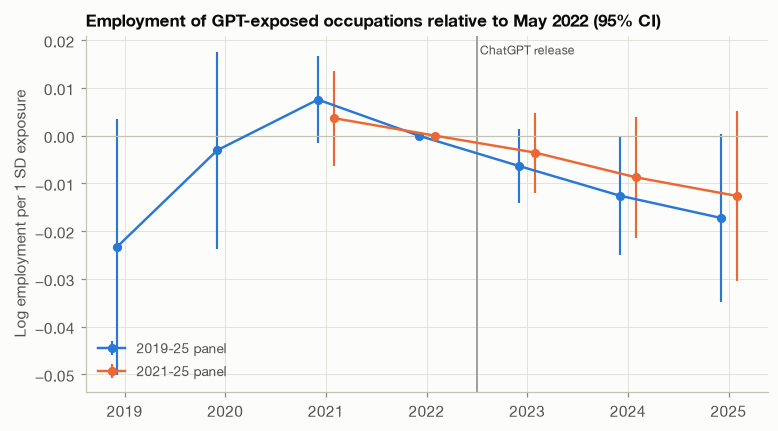

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.2))
for (k, c, off) in [("Employment, 2019-25 panel", BLUE, -0.08), ("Employment, 2021-25 panel", ORANGE, 0.08)]:
    e = es[k]
    ax.errorbar(e.index + off, e.coef, yerr=1.96 * e.se, color=c, marker="o", ms=5, lw=1.6, capsize=0,
                elinewidth=1.4, label=k.replace("Employment, ", ""))
ax.axhline(0, color=BASELINE, lw=0.8)
mark_chatgpt(ax, x=2022.5)
ax.set_xticks(range(2019, 2026))
ax.set_ylabel("Log employment per 1 SD exposure")
ax.set_title("Employment of GPT-exposed occupations relative to May 2022 (95% CI)")
ax.legend(loc="lower left")
save(fig, "03_oews_exposure_event_study_employment");

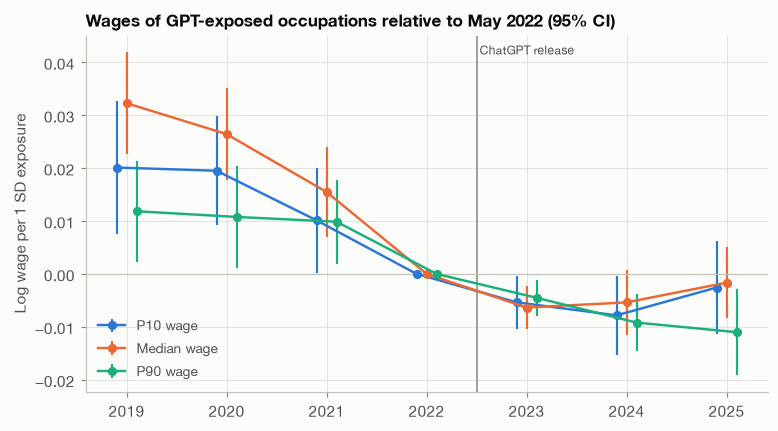

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.2))
for (k, c, off) in [("P10 wage, 2019-25", BLUE, -0.1), ("Median wage, 2019-25", ORANGE, 0.0), ("P90 wage, 2019-25", AQUA, 0.1)]:
    e = es[k]
    ax.errorbar(e.index + off, e.coef, yerr=1.96 * e.se, color=c, marker="o", ms=5, lw=1.6, capsize=0,
                elinewidth=1.4, label=k.replace(", 2019-25", ""))
ax.axhline(0, color=BASELINE, lw=0.8)
mark_chatgpt(ax, x=2022.5)
ax.set_xticks(range(2019, 2026))
ax.set_ylabel("Log wage per 1 SD exposure")
ax.set_title("Wages of GPT-exposed occupations relative to May 2022 (95% CI)")
ax.legend(loc="lower left")
save(fig, "03_oews_exposure_event_study_wages");

## 4. Employment growth by exposure quintile: 2019–22 (pre) vs 2022–25 (post)

,2019-22 (pre),2022-25 (post),n_occ
quintile,,,
Q1 least,-2.37,3.22,142.0
Q2,-4.17,4.81,141.0
Q3,-0.78,5.39,141.0
Q4,11.53,6.21,141.0
Q5 most,-0.68,-0.34,141.0


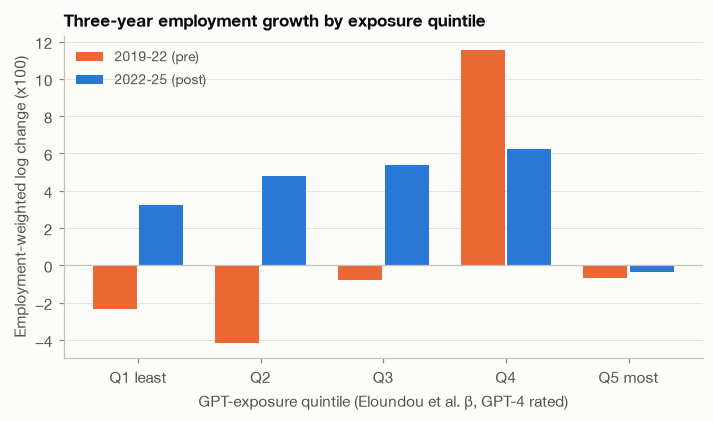

In [10]:
wide = p19.pivot_table(index="OCC_CODE", columns="YEAR", values="TOT_EMP")
g = pd.DataFrame({"2019-22 (pre)": np.log(wide[2022] / wide[2019]), "2022-25 (post)": np.log(wide[2025] / wide[2022])})
g = g.join(exp6.dv_rating_beta).join(wide[2022].rename("w"))
g["quintile"] = pd.qcut(g.dv_rating_beta, 5, labels=["Q1 least", "Q2", "Q3", "Q4", "Q5 most"])
quint = g.groupby("quintile", observed=True).apply(
    lambda x: pd.Series({c: wavg(x[c], x.w) * 100 for c in ["2019-22 (pre)", "2022-25 (post)"]} | {"n_occ": len(x)}))
display(quint.round(2))

fig, ax = plt.subplots(figsize=(7.5, 3.8))
xpos = np.arange(5); w = 0.36
for i, (col, c) in enumerate([("2019-22 (pre)", ORANGE), ("2022-25 (post)", BLUE)]):
    ax.bar(xpos + (i - 0.5) * (w + 0.02), quint[col], width=w, color=c, label=col)
ax.set_xticks(xpos, quint.index)
ax.axhline(0, color=BASELINE, lw=0.8)
ax.grid(axis="x", visible=False)
ax.set_ylabel("Employment-weighted log change (x100)")
ax.set_xlabel("GPT-exposure quintile (Eloundou et al. β, GPT-4 rated)")
ax.set_title("Three-year employment growth by exposure quintile")
ax.legend(loc="upper left")
save(fig, "03_oews_growth_by_exposure_quintile");

In [11]:
p19.to_csv(PROCESSED / "oews_exposure_panel_2019_2025.csv", index=False)
emp.to_csv(PROCESSED / "oews_computer_occupations_employment.csv")
es_tab.to_csv(PROCESSED / "oews_exposure_event_study.csv")
print("saved processed OEWS tables")

saved processed OEWS tables


## Findings

1. **Software-developer employment kept growing after 2022, but more slowly.** Harmonized software developers & QA testers went from 1.41M (May 2019) to 1.73M (May 2022, +23%) to 1.87M (May 2025, +8.3%). Almost all of the post-2022 growth came in 2023, and 2023–2025 is flat. **Computer programmers** have shrunk steadily: −34% over 2019–22 and −31% over 2022–25, to 92k. That decline predates LLMs.
2. **The software wage distribution compressed rather than diverged.**
   - For software developers (15-1252) from May 2022 to May 2025, P10 rose 15.7% ($71.3k → $82.5k), the median 6.9%, and P90 8.4%. P90/P10 fell from 2.78 to 2.60.
   - If P10 proxies entry-level pay, this is the opposite of an occupation-level *wage* junior penalty.
   - The caveat matters: fewer junior hires would empty the bottom of the distribution and raise P10 mechanically.
3. **Across about 700 occupations, exposure predicts slightly slower employment growth after 2022, on top of a pre-trend.**
   - 2019–25 panel, weighted: a 1-SD more exposed occupation had 0.6%, 1.3% and 1.7% lower employment in 2023, 2024 and 2025 relative to 2022 (SE 0.4–0.9 pp; the 2024 estimate is significant at 5%).
   - Before 2022 the same occupations were growing *faster* (2019 coefficient −2.3%, SE 1.4).
   - Unweighted, the post-2022 effect is about zero and the pre-trend is larger. Human-rated exposure gives smaller, insignificant effects.
   - **It does not survive a change of exposure measure.** Felten, Raj & Seamans' (2021) AIOE correlates 0.85 with the GPT-4 β and matches 93% of the occupations. With AIOE, the post-2022 coefficients are +0.002, +0.000 and +0.001, while the same pre-trend appears (2019: −0.026, SE 0.011).
4. **The most-exposed quintile is the only one that shrank over 2022–25:** −0.3%, versus +3.2% to +6.2% for the others. It was also flat in 2019–22 (−0.7%), so its lag is not new.
5. **Wages.** In exposed occupations, P90 wages grew about 1.1% less per SD by 2025 (SE 0.4). P10 effects are small and insignificant.

**Interpretation.** OEWS shows no occupation-wide collapse in software employment and no widening of the software wage distribution. Cross-occupation exposure effects are small. OEWS measures employment stocks, smoothed over three years, and has no experience variable, so a junior-specific *hiring* effect would register only weakly here.